# 05 — Consumer Spending Analysis

## Objective

Test the secondary research questions directly: how does income relate to spending, how does inflation relate to growth, and how does digitalisation relate to spending? Correlation only — **no causal claims are made anywhere in this notebook.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src/visualisation')
snap = pd.read_csv('../data/processed/latest_year_snapshot.csv')
corr = pd.read_csv('../outputs/tables/correlation_analysis.csv')
corr

,pair,n,pearson_r,p_value
0,GDP per capita (PPP) vs Consumption per capita,166,0.877,0.00000
1,Internet penetration vs Consumption per capita,154,0.607,0.00000
2,Internet penetration vs Consumption CAGR,154,-0.219,0.00628
3,Inflation vs YoY real consumption growth,153,-0.083,0.30833
4,Urbanisation vs Consumption per capita,171,0.625,0.00000
5,Aging population (65+) vs Consumption share of...,182,-0.325,0.00001
6,GDP per capita (PPP) vs Consumption CAGR (conv...,166,-0.136,0.07960


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
import matplotlib.pyplot as plt

ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Income vs. consumer spending — the strongest relationship in the dataset

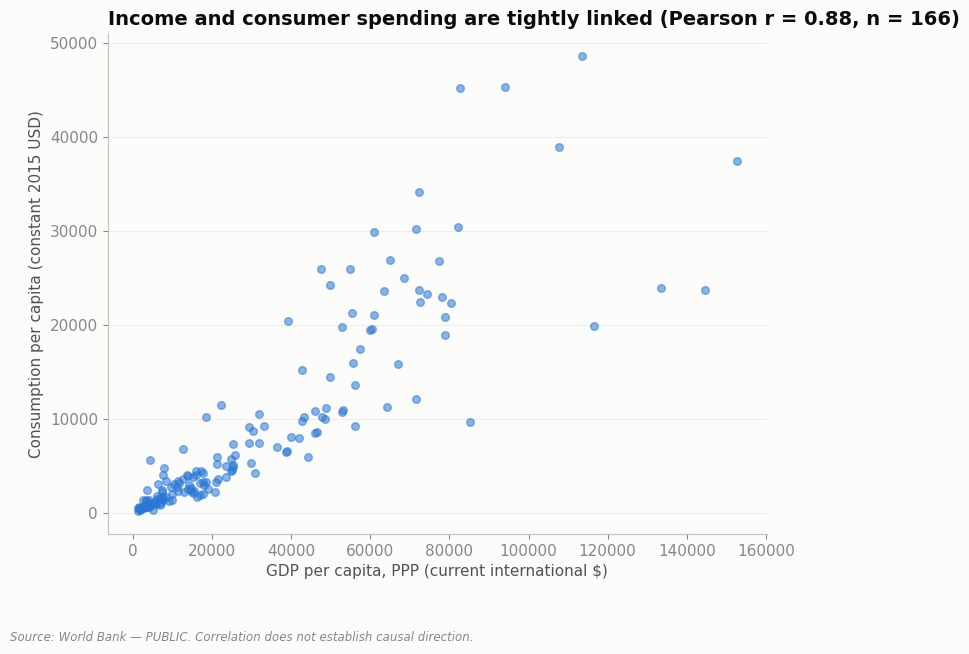

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
d = snap.dropna(subset=['gdp_per_capita_ppp_current_intl','household_consumption_expenditure_per_capita_constant_2015_usd'])
ax.scatter(d['gdp_per_capita_ppp_current_intl'], d['household_consumption_expenditure_per_capita_constant_2015_usd'], s=30, alpha=0.55, color=ACCENT_1)
ax.set_title('Income and consumer spending are tightly linked (Pearson r = 0.88, n = 166)', loc='left')
ax.set_xlabel('GDP per capita, PPP (current international $)')
ax.set_ylabel('Consumption per capita (constant 2015 USD)')
add_source(ax.figure, 'Source: World Bank \u2014 PUBLIC. Correlation does not establish causal direction.')
plt.show()

## Inflation vs. real spending growth — no strong relationship

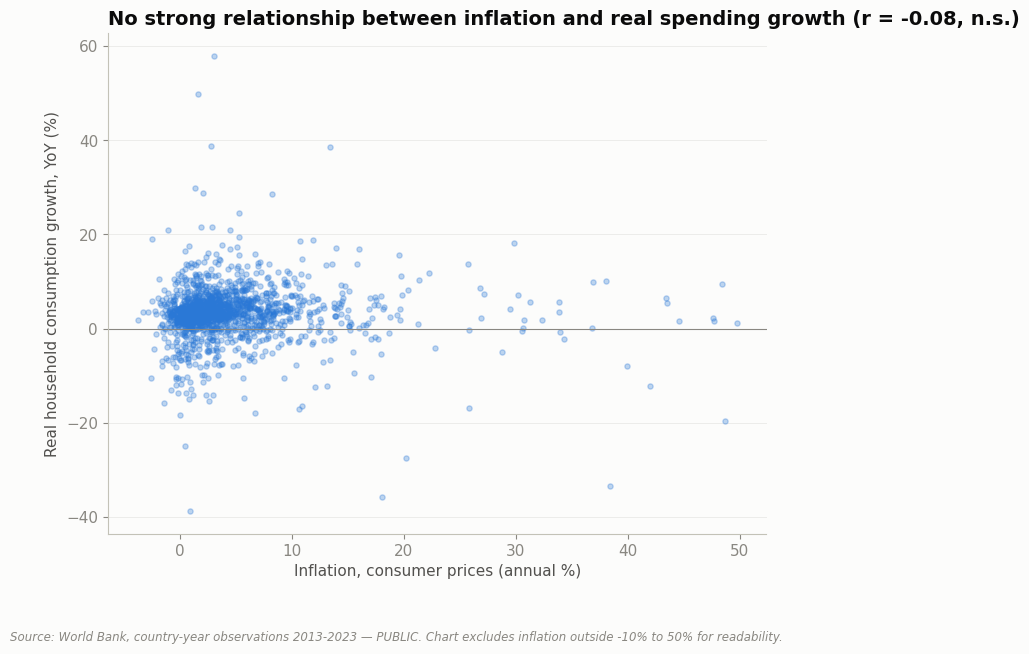

In [4]:
master = pd.read_csv('../data/processed/master_consumer_spending.csv')
d8 = master.dropna(subset=['inflation_cpi_annual_pct','consumption_growth_yoy_real_pct'])
d8_plot = d8[d8['inflation_cpi_annual_pct'].between(-10, 50)]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.scatter(d8_plot['inflation_cpi_annual_pct'], d8_plot['consumption_growth_yoy_real_pct'], s=14, alpha=0.3, color=ACCENT_1)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_title('No strong relationship between inflation and real spending growth (r = -0.08, n.s.)', loc='left')
ax.set_xlabel('Inflation, consumer prices (annual %)')
ax.set_ylabel('Real household consumption growth, YoY (%)')
add_source(ax.figure, 'Source: World Bank, country-year observations 2013-2023 \u2014 PUBLIC. Chart excludes inflation outside -10% to 50% for readability.')
plt.show()

## Findings, Stated With Appropriate Uncertainty

- **Income appears to be the dominant explanatory factor for spending levels** (r=0.88) — this is expected and consistent with basic consumption theory (higher income affords higher spending), not a novel finding, but the strength of the relationship in this dataset is a useful sanity check that the underlying data behaves as economic theory predicts.
- **Digitalisation (internet penetration) is associated with higher spending per capita** (r=0.61) and **is associated with slower spending growth** (r=-0.22) — consistent with digitalisation being a marker of market maturity: already-developed, already-online markets tend to be large but growing more slowly than markets still digitalising.
- **Inflation shows no meaningful linear relationship with real spending growth** in this sample (r=-0.08, not statistically significant, p=0.31) — this does *not* mean inflation is irrelevant to consumers (real wages, substitution effects, and category-level effects are not captured by this aggregate test), only that a simple country-year linear relationship does not show up at this level of aggregation.
- **None of these relationships should be read as causal.** Higher income may enable more spending, but reverse or third-factor explanations (e.g. both driven by institutional quality, trade openness, or resource wealth) cannot be ruled out with this data alone.